## Module 5(2) - Ensemble Models
Asst. Prof. Dr. Santitham Prom-on

---

# 1. Load data

In [1]:
!wget https://github.com/santitham/data-science/raw/refs/heads/main/data/hr_attrition.data

--2025-10-29 06:40:55--  https://github.com/santitham/data-science/raw/refs/heads/main/data/hr_attrition.data
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/santitham/data-science/refs/heads/main/data/hr_attrition.data [following]
--2025-10-29 06:40:55--  https://raw.githubusercontent.com/santitham/data-science/refs/heads/main/data/hr_attrition.data
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 340581 (333K) [application/octet-stream]
Saving to: ‘hr_attrition.data’

hr_attrition.data   100%[===================>] 332.60K  --.-KB/s    in 0.005s  

2025-10-29 06:40:55 (67.1 MB/s) - ‘hr_attrition

In [2]:
import pickle

X_train, X_test, y_train, y_test = \
    pickle.load(open('hr_attrition.data','rb'))

In [3]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1029, 44)
(441, 44)
(1029,)
(441,)


# 2. Modeling - Random Forest

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(min_samples_leaf=20, max_depth=8, class_weight='balanced')
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=20)

In [5]:
import pandas as pd

pd.DataFrame(dict(Feature=rf.feature_names_in_,
                  Value=rf.feature_importances_))\
  .sort_values(by='Value', ascending=False)\
  .head(20)

,Feature,Value
30,MonthlyIncome,0.099516
20,OverTime_Yes,0.094838
40,YearsAtCompany,0.073309
36,StockOptionLevel,0.055755
21,Age,0.052026
28,JobLevel,0.048314
43,YearsWithCurrManager,0.047665
22,DailyRate,0.043609
37,TotalWorkingYears,0.043502
41,YearsInCurrentRole,0.043165


In [6]:
rf

RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=20)

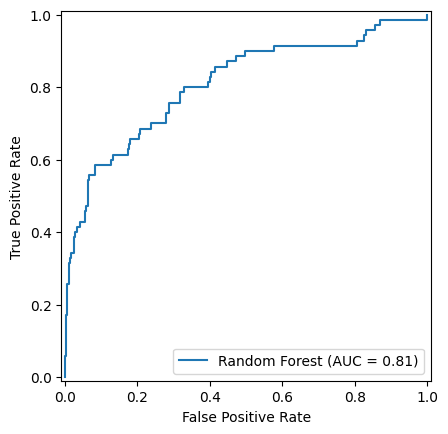

In [7]:
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

y_res = rf.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_res[:,1])
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='Random Forest')
display.plot()

In [8]:
df = pd.read_csv('http://fastdata.in.th/GSB/bank-data.csv', sep=';')
df.head()

HTTPError: HTTP Error 404: Not Found

In [ ]:
# 1. separate numeric data
df_num = df.select_dtypes('number')
df_num.drop(columns='duration', inplace=True)
df_num

In [ ]:
df_num.describe().T

In [ ]:
df_cat = df.select_dtypes('object')
df_cat

In [ ]:
df_cat_bin = pd.get_dummies(df_cat, drop_first=True)
df_cat_bin

In [ ]:
# 4. combine data
df_prep = pd.concat([df_num, df_cat_bin], axis=1)
df_prep

In [ ]:
pd.crosstab(df_prep['y_yes'], columns='N', normalize=True)

In [ ]:
X = df_prep.drop(columns='y_yes')
y = df_prep['y_yes']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=777)

In [ ]:
pd.crosstab(y_train, columns='N', normalize=True)

In [ ]:
pd.crosstab(y_test, columns='N', normalize=True)

In [ ]:
model = RandomForestClassifier(n_estimators=500,max_samples=0.5,class_weight='balanced')
model.fit(X_train, y_train)

In [ ]:
y_res = model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_res[:,1])
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='Random Forest')
display.plot()

In [ ]:
pd.DataFrame({'Feature':model.feature_names_in_,
              'Score':model.feature_importances_})\
  .sort_values(by='Score', ascending=False)\
  .head(20)

# 3. Gradient Boosting

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(min_samples_leaf=20, n_estimators=200)
gbc.fit(X_train, y_train)

GradientBoostingClassifier(min_samples_leaf=20, n_estimators=200)

In [10]:
import pandas as pd

pd.DataFrame(dict(Feature=gbc.feature_names_in_,
                  Value=gbc.feature_importances_))\
  .sort_values(by='Value', ascending=False)\
  .head(20)

,Feature,Value
30,MonthlyIncome,0.132644
20,OverTime_Yes,0.102917
21,Age,0.057188
22,DailyRate,0.055768
25,EnvironmentSatisfaction,0.046048
40,YearsAtCompany,0.045459
36,StockOptionLevel,0.043686
23,DistanceFromHome,0.043542
32,NumCompaniesWorked,0.038364
31,MonthlyRate,0.034769


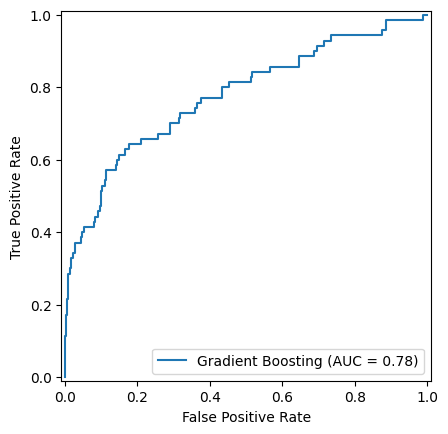

In [11]:
y_res = gbc.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_res[:,1])
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='Gradient Boosting')
display.plot()

# 4. xgBoost

In [12]:
import xgboost as xgb

param = {
    'eta': 0.3,
    'max_depth': 6,
    'objective': 'binary:logistic'
}

steps = 100

In [13]:
D_train = xgb.DMatrix(X_train, label=y_train)
D_test = xgb.DMatrix(X_test, label=y_test)

In [14]:
model = xgb.train(param, D_train, steps)

In [15]:
model

In [16]:
p = model.predict(D_test)
p

array([1.22369931e-03, 2.53893645e-03, 4.02840832e-03, 2.52606720e-03,
       1.62959122e-03, 1.56828649e-02, 9.85109434e-02, 2.72048023e-02,
       1.03966556e-02, 1.08819408e-03, 8.60747241e-04, 5.05395234e-03,
       1.69531405e-01, 4.78137459e-04, 2.24315450e-01, 1.72702391e-02,
       4.17223712e-03, 3.49641412e-01, 3.79211339e-03, 1.36165498e-02,
       8.06704571e-04, 8.53983045e-01, 5.86637974e-01, 3.15055414e-03,
       1.26073202e-02, 5.54129183e-02, 4.29018512e-02, 3.52528150e-04,
       7.12266490e-02, 8.46688915e-03, 9.98604953e-01, 2.76144408e-02,
       4.09212138e-04, 4.48397435e-02, 1.37215742e-04, 5.01903007e-03,
       1.31542489e-01, 6.28379524e-01, 8.41112807e-03, 5.23420656e-03,
       5.55341579e-02, 1.50462210e-01, 2.33425871e-02, 6.41855318e-03,
       6.23304571e-04, 9.95626569e-01, 2.62501389e-02, 4.77976585e-03,
       2.41550934e-02, 4.12671268e-01, 6.04052246e-02, 3.24960332e-03,
       3.15806806e-01, 6.52322769e-02, 6.68658831e-05, 2.44757552e-02,
      

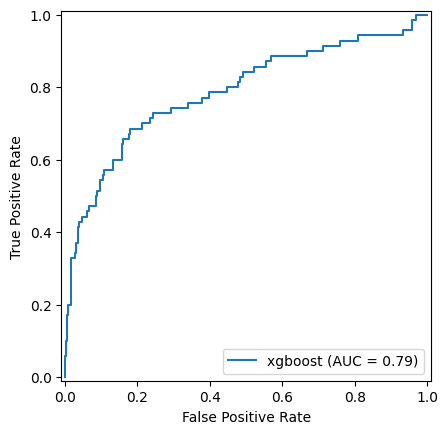

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, p)
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='xgboost')
display.plot()

In [18]:
model.get_score(importance_type='total_gain')

{'BusinessTravel_Travel_Frequently': 29.424396514892578,
 'BusinessTravel_Travel_Rarely': 1.8402150869369507,
 'Department_Research & Development': 9.055212020874023,
 'Department_Sales': 3.537611246109009,
 'EducationField_Life Sciences': 3.9540421962738037,
 'EducationField_Marketing': 9.82841682434082,
 'EducationField_Medical': 6.5144782066345215,
 'EducationField_Technical Degree': 12.238059997558594,
 'Gender_Male': 17.146570205688477,
 'JobRole_Laboratory Technician': 13.105971336364746,
 'JobRole_Manufacturing Director': 1.14822256565094,
 'JobRole_Research Scientist': 21.530120849609375,
 'JobRole_Sales Executive': 38.722084045410156,
 'JobRole_Sales Representative': 2.0156149864196777,
 'MaritalStatus_Married': 5.389144420623779,
 'MaritalStatus_Single': 15.683491706848145,
 'OverTime_Yes': 143.70606994628906,
 'Age': 82.09991455078125,
 'DailyRate': 108.61383819580078,
 'DistanceFromHome': 78.45500183105469,
 'Education': 22.262073516845703,
 'EnvironmentSatisfaction': 61.02

In [19]:
sorted(model.get_score(importance_type='total_gain').items(),
       key = lambda x:x[1], reverse = True)

[('MonthlyIncome', 187.93154907226562),
 ('OverTime_Yes', 143.70606994628906),
 ('DailyRate', 108.61383819580078),
 ('HourlyRate', 92.41152954101562),
 ('StockOptionLevel', 90.78182220458984),
 ('YearsAtCompany', 83.25000762939453),
 ('Age', 82.09991455078125),
 ('NumCompaniesWorked', 81.74028015136719),
 ('DistanceFromHome', 78.45500183105469),
 ('MonthlyRate', 64.6155776977539),
 ('EnvironmentSatisfaction', 61.020965576171875),
 ('PercentSalaryHike', 59.1016960144043),
 ('JobSatisfaction', 53.731563568115234),
 ('YearsSinceLastPromotion', 52.616363525390625),
 ('TotalWorkingYears', 39.954444885253906),
 ('JobRole_Sales Executive', 38.722084045410156),
 ('RelationshipSatisfaction', 35.87763595581055),
 ('YearsWithCurrManager', 31.07999038696289),
 ('WorkLifeBalance', 30.911605834960938),
 ('BusinessTravel_Travel_Frequently', 29.424396514892578),
 ('JobInvolvement', 27.348697662353516),
 ('JobLevel', 23.804187774658203),
 ('TrainingTimesLastYear', 22.332612991333008),
 ('Education', 22